# WASD Imitation Learning
In this notebook, I explore the concept of Imitation Learning/Behaviour Cloning by playing a game I built myself named WASD. I first play the game myself to gather "expert data" which can then be used to train a model to play the game like how I would.

### Collecting Data
This block allows the user to play the game and gather data to train the model

In [44]:
import gymnasium as gym
import numpy as np
import pickle
import keyboard  # Import the keyboard library
from WASDEnv import WinFormsGameEnv
from helper import alt_tab
import time

# Initialize environment
env = WinFormsGameEnv(action_pipeline=False)
obs, _ = env.reset()

# Data storage
obs_list = []
action_list = []

# Limit the data collection to 50 states
max_states = 30
state_counter = 0

def get_user_action():
    # Use the keyboard library to check which key is pressed
    if keyboard.is_pressed('w'):  # Move up
        return 0
    elif keyboard.is_pressed('a'):  # Move left
        return 1
    elif keyboard.is_pressed('s'):  # Move down
        return 2
    elif keyboard.is_pressed('d'):  # Move right
        return 3
    else:
        return None  # No action pressed

while state_counter < max_states:
    user_action = get_user_action() # get user action
    # game processes this action
    if user_action is not None:
        obs_list.append(obs)
        action_list.append(user_action)
        state_counter += 1

        # Step in the environment
        time.sleep(.25) # give env time to process the input
        obs, reward, terminated, truncated, _ = env.step(user_action)
        done = terminated or truncated
        if done:
            obs, _ = env.reset()

        # Wait until all WASD keys are released before continuing
        while any(keyboard.is_pressed(k) for k in ['w', 'a', 's', 'd']):
            time.sleep(0.01)  # small delay to prevent busy waiting


# Save data
with open("WASD_demos.pkl", "wb") as f:
    pickle.dump((obs_list, action_list), f)

print("🎉 Saved", len(obs_list), "frames of expert data!")


alt_tab()


🎉 Saved 30 frames of expert data!


### Concatenate Data
Code to concatenate multiple expert runs (if there are multiple)

In [38]:
import pickle

# File paths for each of your individual demo files
file_paths = [
    "WASD_demos_combined.pkl",
    "WASD_demos_more.pkl",
]

# Initialize empty lists to hold the concatenated observations and actions
all_obs = []
all_actions = []

# Load each of the .pkl files and append the data
for file_path in file_paths:
    with open(file_path, 'rb') as f:
        obs_list, action_list = pickle.load(f)
        all_obs.extend(obs_list)  # Concatenate observations
        all_actions.extend(action_list)  # Concatenate actions

# Save the concatenated data to a new .pkl file
with open("WASD_demos_combined.pkl", 'wb') as f:
    pickle.dump((all_obs, all_actions), f)

print(f"🎉 Concatenated and saved {len(all_obs)} frames of expert data!")


🎉 Concatenated and saved 96 frames of expert data!


## Data Insights
Inspecting how much data there is for each state. There are only 4 different states, meaning a low amount of data is sufficient for this project. Important is that there are at least a few states per letter, so that the model won't think the score and letter are connected.

In [45]:
import numpy as np
import pickle

with open("WASD_demos.pkl", "rb") as f:
    obs_list, action_list = pickle.load(f)

actions = np.array(action_list)
print("Action 0 count:", np.sum(actions == 0))
print("Action 1 count:", np.sum(actions == 1))
print("Action 2 count:", np.sum(actions == 2))
print("Action 3 count:", np.sum(actions == 3))


Action 0 count: 5
Action 1 count: 6
Action 2 count: 7
Action 3 count: 12


## Train model on expert data

In [46]:
import torch
import gymnasium as gym
import numpy as np
import pickle
import keyboard  # Import the keyboard library
from WASDEnv import WinFormsGameEnv
from helper import alt_tab
import time 
from torch.utils.data import TensorDataset, DataLoader
from DQNCNN import DQNCNN
import torch
import torch.nn as nn
import torch.optim as optim


# Convert obs_list to numpy array
obs_array = np.array(obs_list)  # Shape: (batch_size, 84, 84)

# Add a channel dimension (1 channel for grayscale images)
obs_array = obs_array[:, np.newaxis, :, :]  # New shape: (batch_size, 1, 84, 84)

# Convert to tensors
obs_tensor = torch.FloatTensor(obs_array)  # Shape: (batch_size, 1, 84, 84)
actions_tensor = torch.LongTensor(action_list)

# Create DataLoader
dataset = TensorDataset(obs_tensor, actions_tensor)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

# Instantiate model with action_size and stack_size = 1
bc_model = DQNCNN(action_size=4, stack_size=1)  # Make sure action_size matches your setup
# bc_model.load_state_dict(torch.load("bc_model.pth"))
optimizer = optim.Adam(bc_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Training loop
for epoch in range(50):
    for batch_obs, batch_act in dataloader:
        print("Input shape to model:", batch_obs.shape)  # Should be (batch_size, 1, 84, 84)
        logits = bc_model(batch_obs)
        loss = criterion(logits, batch_act)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch + 1} | Loss: {loss.item():.4f}")

# Save the model
torch.save(bc_model.state_dict(), "bc_model.pth")


Input shape to model: torch.Size([30, 1, 84, 84])
Epoch 1 | Loss: 1.3820
Input shape to model: torch.Size([30, 1, 84, 84])
Epoch 2 | Loss: 3.3448
Input shape to model: torch.Size([30, 1, 84, 84])
Epoch 3 | Loss: 0.8905
Input shape to model: torch.Size([30, 1, 84, 84])
Epoch 4 | Loss: 0.6563
Input shape to model: torch.Size([30, 1, 84, 84])
Epoch 5 | Loss: 0.7142
Input shape to model: torch.Size([30, 1, 84, 84])
Epoch 6 | Loss: 0.6034
Input shape to model: torch.Size([30, 1, 84, 84])
Epoch 7 | Loss: 0.3641
Input shape to model: torch.Size([30, 1, 84, 84])
Epoch 8 | Loss: 0.3185
Input shape to model: torch.Size([30, 1, 84, 84])
Epoch 9 | Loss: 0.3622
Input shape to model: torch.Size([30, 1, 84, 84])
Epoch 10 | Loss: 0.3266
Input shape to model: torch.Size([30, 1, 84, 84])
Epoch 11 | Loss: 0.2917
Input shape to model: torch.Size([30, 1, 84, 84])
Epoch 12 | Loss: 0.3011
Input shape to model: torch.Size([30, 1, 84, 84])
Epoch 13 | Loss: 0.2653
Input shape to model: torch.Size([30, 1, 84, 84

## Verify the data
Below are samples to confirm that the data is labeled correctly.


C:\Users\Kaan\AppData\Local\Temp\ipykernel_12172\3557757798.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  bc_model.load_state_dict(torch.load("bc_model.pth"))


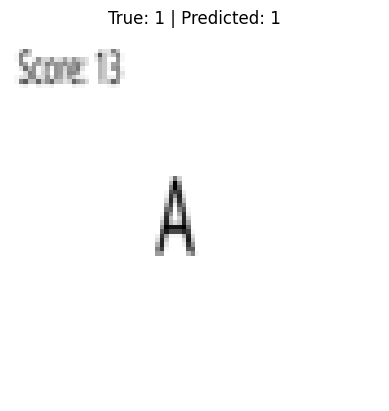

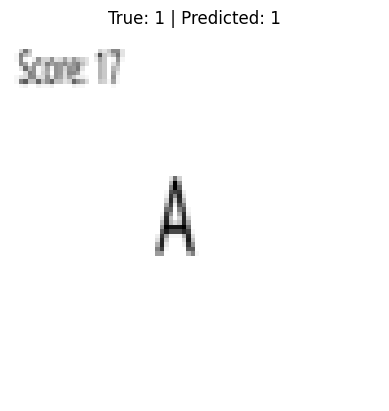

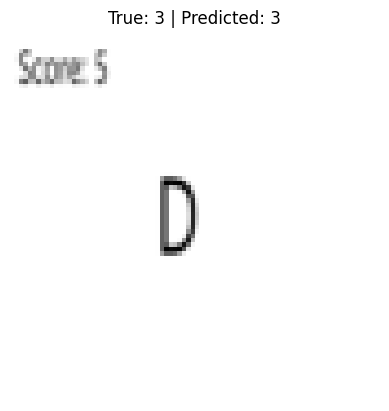

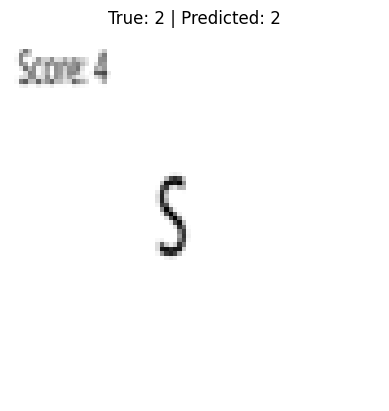

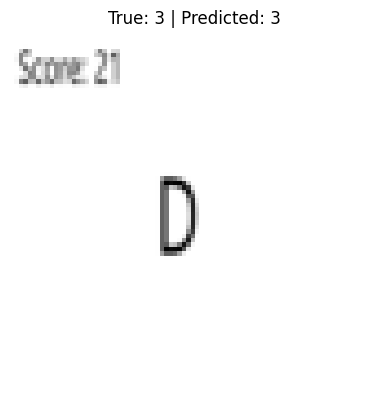

In [47]:
import torch
import matplotlib.pyplot as plt
import random
import pickle
import numpy as np
from DQNCNN import DQNCNN

# === Load data ===
with open("WASD_demos.pkl", "rb") as f:
    obs_list, action_list = pickle.load(f)

# Preprocess
obs_array = np.array(obs_list)  # (N, 84, 84)
obs_array = obs_array[:, np.newaxis, :, :]  # (N, 1, 84, 84)
obs_tensor = torch.FloatTensor(obs_array)
actions_tensor = torch.LongTensor(action_list)

# === Load trained model ===
bc_model = DQNCNN(action_size=4, stack_size=1)
bc_model.load_state_dict(torch.load("bc_model.pth"))
bc_model.eval()

# === Visualize predictions on 5 random samples ===
sample_indices = random.sample(range(len(obs_tensor)), 5)

for idx in sample_indices:
    obs_sample = obs_tensor[idx].unsqueeze(0)  # (1, 1, 84, 84)
    true_action = actions_tensor[idx].item()

    with torch.no_grad():
        logits = bc_model(obs_sample)
        pred_action = torch.argmax(logits, dim=1).item()

    # Plot image
    image = obs_sample.squeeze().cpu().numpy()  # (84, 84)
    plt.imshow(image, cmap='gray')
    plt.title(f"True: {true_action} | Predicted: {pred_action}")
    plt.axis('off')
    plt.show()


## Testing the model
Below the code to test the model

In [66]:
import torch
import numpy as np
import pickle
from DQNCNN import DQNCNN
from WASDEnv import WinFormsGameEnv  # or your custom gym env

# Load trained model
model = DQNCNN(action_size=4, stack_size=1)
model.load_state_dict(torch.load("bc_model.pth"))
model.eval()

# Create environment
env = WinFormsGameEnv()
obs, _ = env.reset()

done = False
score = 0
while not done and score < 10:
    # Preprocess observation: (84, 84) -> (1, 1, 84, 84)
    obs_tensor = torch.FloatTensor(obs).unsqueeze(0).unsqueeze(0)  # Add batch and channel dims

    # Get model prediction
    with torch.no_grad():
        logits = model(obs_tensor)
        action = torch.argmax(logits, dim=1).item()

    # Take action in env
    time.sleep(.00002)
    obs, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    score+=1

env.close()
print(score)


C:\Users\Kaan\AppData\Local\Temp\ipykernel_12172\175402815.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("bc_model.pth"))


10


# Gradcam to inspect the results
The gradcam shows where the model exactly looks at when calculating what action to choose. There are 5 samples below which in the model tries to predict an action using a state, and in all cases it was correct.

In [67]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
import cv2

# Store gradients and activations
grads = []
activations = []

# Hook functions
def save_activation(module, input, output):
    activations.append(output.detach())

def save_gradient(module, grad_input, grad_output):
    grads.append(grad_output[0].detach())

# Register hooks on the last conv layer
target_layer = model.conv1
target_layer.register_forward_hook(save_activation)
target_layer.register_backward_hook(save_gradient)


C:\Users\Kaan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\nn\modules\module.py:1640: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


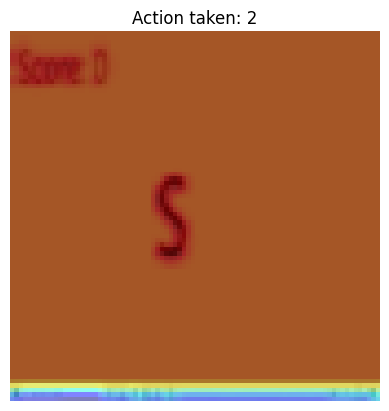

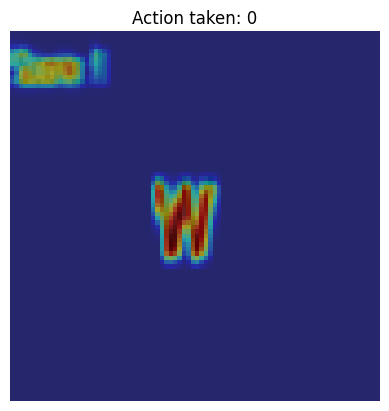

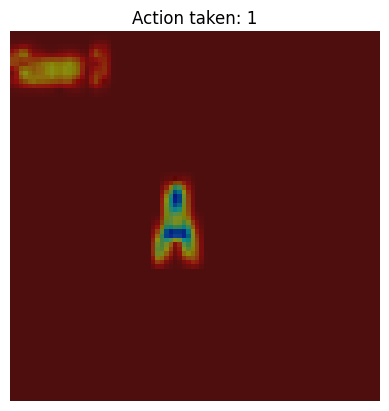

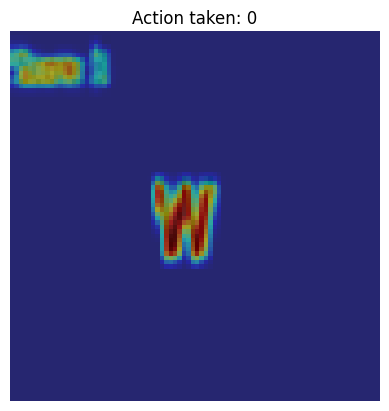

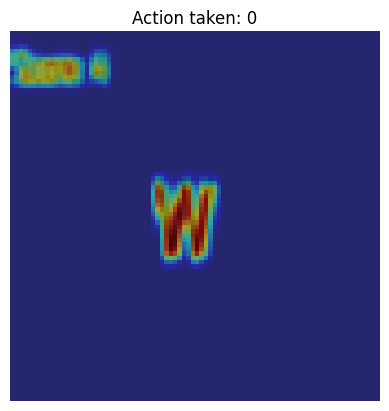

In [70]:
obs, _ = env.reset()
done = False

x = 0
while x < 5:
    x+=1
    
    time.sleep(0.5)
    
    grads.clear()
    activations.clear()
    
    obs_tensor = torch.FloatTensor(obs).unsqueeze(0).unsqueeze(0).requires_grad_()

    with torch.no_grad():
        logits = model(obs_tensor)
    action = torch.argmax(logits, dim=1).item()

    # Now run again with gradient tracking for Grad-CAM
    logits = model(obs_tensor)
    score = logits[0, action]  # Only backprop through selected action
    model.zero_grad()
    score.backward()

    # Compute Grad-CAM
    grad = grads[0]  # [batch, channels, h, w]
    activation = activations[0]  # Same shape

    weights = grad.mean(dim=(2, 3), keepdim=True)  # Global Average Pooling
    cam = (weights * activation).sum(dim=1).squeeze()  # Weighted sum

    cam = F.relu(cam)
    cam -= cam.min()
    cam /= cam.max()
    cam = cam.cpu().numpy()
    cam = cv2.resize(cam, (84, 84))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    obs_np = obs.cpu().numpy() if torch.is_tensor(obs) else obs  # ensure it's NumPy
    obs_img = (obs_np * 255).astype(np.uint8)

    # Handle grayscale conversion properly
    if len(obs_img.shape) == 2:  # If shape is (84, 84)
        obs_img = cv2.cvtColor(obs_img, cv2.COLOR_GRAY2BGR)

    overlay = cv2.addWeighted(obs_img, 0.5, heatmap, 0.5, 0)


    plt.imshow(overlay)
    plt.title(f"Action taken: {action}")
    plt.axis("off")
    plt.show()

    # Take action in env
    time.sleep(.002)
    obs, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

env.close()
